<h1 style="text-align: center; font-family: 'Roboto', sans-serif; font-weight:bold; font-size:40px; margin: 40px 0">05 - Modélisation</h1>

### Objectif
Ce notebook couvre la **modélisation prédictive** de l'attrition RH à partir du dataset consolidé `merged_data.csv`.
L'objectif est de construire un classifieur binaire (`has_left`) robuste en respectant les contraintes de fuite de données,
de déséquilibre de classe et d'interprétabilité.

### Plan de ce notebook
1. Importation des bibliothèques nécessaires
2. Chargement & inspection du dataset final
3. Sélection et préparation des features
4. Séparation Train / Test (stratifiée)
5. Preprocessing & Pipeline sklearn
6. Entraînement & Validation croisée stratifiée
7. Évaluation sur le test set
8. Interprétabilité du modèle
9. Réflexion Éthique

### Prérequis
- Avoir exécuté les notebooks [EDA - Données Statiques](./01_eda_static_data.ipynb), [EDA - Feature Engineering Temporel](./02_eda_temporal_and_outliers.ipynb), [EDA - Fusion des Données](./03_eda_merge_data.ipynb) et [EDA - Analyse](./04_eda_analysis.ipynb).
- Le fichier `src/data/processed/merged_data.csv` doit exister.

---
## **1. Importation des bibliothèques nécessaires**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Chemins
DATA_FILE_PATH = '../data/processed/merged_data.csv'

# Configuration du ML
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5
TARGET_COL = 'has_left'

# Styles Visuels
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE     = {0: '#4A90D9', 1: '#E05C5C'}
SNS_PALETTE = ['#4A90D9', '#E05C5C']
LABELS      = {0: 'Resté (0)', 1: 'Parti (1)'}

print('Les bibliothèques ont été importées correctement !')

Les bibliothèques ont été importées correctement !


---
## **2. Chargement & inspection du dataset final**

In [27]:
df = pd.read_csv(DATA_FILE_PATH)
print(f"Dimensions : {df.shape}")
print(f"\nRépartition de la cible '{TARGET_COL}' :")
print(df[TARGET_COL].value_counts())
print(f"\nTaux d'attrition : {df[TARGET_COL].mean():.1%}")
df.head()

Dimensions : (4410, 25)

Répartition de la cible 'has_left' :
has_left
0    3699
1     711
Name: count, dtype: int64

Taux d'attrition : 16.1%


,has_left,business_travel,department,education,education_field,employee_id,job_level,job_role,monthly_income,percent_salary_hike,...,environment_satisfaction,job_satisfaction,work_life_balance,job_involvement,performance_rating,avg_hours_per_day,std_hours_daily,std_hours_monthly,total_days_worked,overtime_ratio
0,0,1,Sales,2,LifeSci,1,1,HealthRep,131160,11,...,3,4,2,3,3,7.373651,0.283224,0.051012,232,0.000000
1,1,2,R&D,1,LifeSci,2,1,Scientist,41890,23,...,3,2,4,2,4,7.718969,0.313351,0.080174,236,0.177966
2,0,2,R&D,4,Other,3,4,SalesExec,193280,15,...,2,2,1,3,3,7.013240,0.311551,0.069011,242,0.000000
3,0,0,R&D,5,LifeSci,4,3,HR,83210,11,...,4,4,3,2,3,7.193678,0.284133,0.069819,235,0.000000
4,0,1,R&D,1,Medical,5,1,SalesExec,23420,12,...,4,1,3,3,3,8.006175,0.300656,0.048139,245,0.469388


---
## **3. Sélection et préparation des features**

Avant de séparer les données, il faut décider quelles features conserver.
Le notebook 04 a mis en évidence une forte corrélation (`0.91`) entre `avg_hours_per_day` et `overtime_ratio`.
Conserver les deux features fortement corrélées peut fausser l'importance relative des variables dans certains modèles.

In [28]:
COLS_TO_DROP = [
    'overtime_ratio', 'percent_salary_hike', 'years_with_curr_manager'
]

# On sépare les features de la cible
X = df.drop(columns=[TARGET_COL] + COLS_TO_DROP)
y = df[TARGET_COL]

# On récupère les listes de features numériques et catégorielles
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

print(f"Features numériques ({len(numeric_features)}) :")
print(f"  {numeric_features}")
print(f"\nFeatures catégorielles ({len(categorical_features)}) :")
print(f"  {categorical_features}")
print(f"\nX : {X.shape} | y : {y.shape}")
print(f"\nFeatures supprimées : {COLS_TO_DROP}")

Features numériques (18) :
  ['business_travel', 'education', 'employee_id', 'job_level', 'monthly_income', 'total_working_years', 'training_times_last_year', 'years_at_company', 'years_since_last_promotion', 'environment_satisfaction', 'job_satisfaction', 'work_life_balance', 'job_involvement', 'performance_rating', 'avg_hours_per_day', 'std_hours_daily', 'std_hours_monthly', 'total_days_worked']

Features catégorielles (3) :
  ['department', 'education_field', 'job_role']

X : (4410, 21) | y : (4410,)

Features supprimées : ['overtime_ratio', 'percent_salary_hike', 'years_with_curr_manager']


---
## **4. Séparation Train / Test (stratifiée)**

> ⚠️ **Règle absolue :** le split doit être réalisé **avant toute transformation**.
> Appliquer un `StandardScaler` ou un `SMOTE` sur l'ensemble complet constitue une **fuite de données** :
> le modèle exploiterait indirectement des informations du test set pendant l'entraînement.

In [29]:
# On split les données en train/test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# On vérifie la répartition de la cible dans les sets train/test
print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"\nProportions '{TARGET_COL}' :")
print(f"  Total  : {y.mean():.1%}")
print(f"  Train  : {y_train.mean():.1%}")
print(f"  Test   : {y_test.mean():.1%}")

Train : 3528 lignes | Test : 882 lignes

Proportions 'has_left' :
  Total  : 16.1%
  Train  : 16.1%
  Test   : 16.1%


---
## **5. Preprocessing & Pipeline sklearn**

Un `Pipeline` chaîne les transformations et le classifieur en un seul objet.
Cela garantit que le `StandardScaler` est **fitté uniquement sur le train set** à chaque fold de cross-validation,
et appliqué (sans re-fit) sur le fold de validation et le test set final.

In [30]:
# On met en place un préprocessor : StandardScaler sur les variables numériques et OneHotEncoder sur catégorielles
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop',
)

# On définit les modèles à tester avec leurs hyperparamètres
MODELS_CONFIG = {
    'LogisticRegression': {
        'classifier': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),
        'params': {
            'classifier__C': [0.01, 0.1, 1.0, 10.0],
            'classifier__penalty': ['l2'],
        }
    },
    'RandomForest': {
        'classifier': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 15, 20],
            'classifier__min_samples_split': [5, 10],
        }
    },
    'GradientBoosting': {
        'classifier': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [5, 7],
        }
    },
    'SVM': {
        'classifier': SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE, probability=True),
        'params': {
            'classifier__C': [0.1, 1.0, 10.0],
        }
    },
    'KNN': {
        'classifier': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7, 9],
        }
    },
}

print("Modèles configurés pour la comparaison :")

Modèles configurés pour la comparaison :


---
## **6. Entraînement & Comparaison de plusieurs modèles**

`StratifiedKFold` garantit que la proportion de la classe minoritaire (~15%) est conservée dans chaque fold.
`GridSearchCV` explore la grille d'hyperparamètres et sélectionne la combinaison optimisant le ROC-AUC.

In [31]:
# Validation croisée stratifiée
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'roc_auc'

# Entraîner et évaluer tous les modèles
results_models = {}
print(f"{'='*70}")
print(f"{'Modèle':<20} {'Score CV':<15} {'Meilleur Param':<35}")
print(f"{'='*70}")

for model_name, config in MODELS_CONFIG.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', config['classifier']),
    ])
    
    search = GridSearchCV(
        pipe,
        config['params'],
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        verbose=0,
    )
    
    search.fit(X_train, y_train)
    
    results_models[model_name] = {
        'model': search.best_estimator_,
        'grid_search': search,
        'cv_score': search.best_score_,
        'best_params': search.best_params_,
    }
    
    print(f"{model_name:<20} {search.best_score_:.4f}        {str(search.best_params_)[:35]}...")

print(f"{'='*70}")

# Sélectionner le meilleur modèle
best_model_name = max(results_models.keys(), key=lambda x: results_models[x]['cv_score'])
best_model = results_models[best_model_name]['model']

print(f"\n✓ Meilleur modèle : {best_model_name} (ROC-AUC: {results_models[best_model_name]['cv_score']:.4f})")

Modèle               Score CV        Meilleur Param                     


c:\Users\Gamas\Documents\RécupGithub\StableDiffusion\IA-groupe-02\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


LogisticRegression   0.7777        {'classifier__C': 0.1, 'classifier_...
RandomForest         0.9631        {'classifier__max_depth': 20, 'clas...
GradientBoosting     0.9605        {'classifier__learning_rate': 0.1, ...
SVM                  0.9149        {'classifier__C': 10.0}...
KNN                  0.8778        {'classifier__n_neighbors': 3}...

✓ Meilleur modèle : RandomForest (ROC-AUC: 0.9631)


---
## **6.1. Visualisation comparative des modèles**

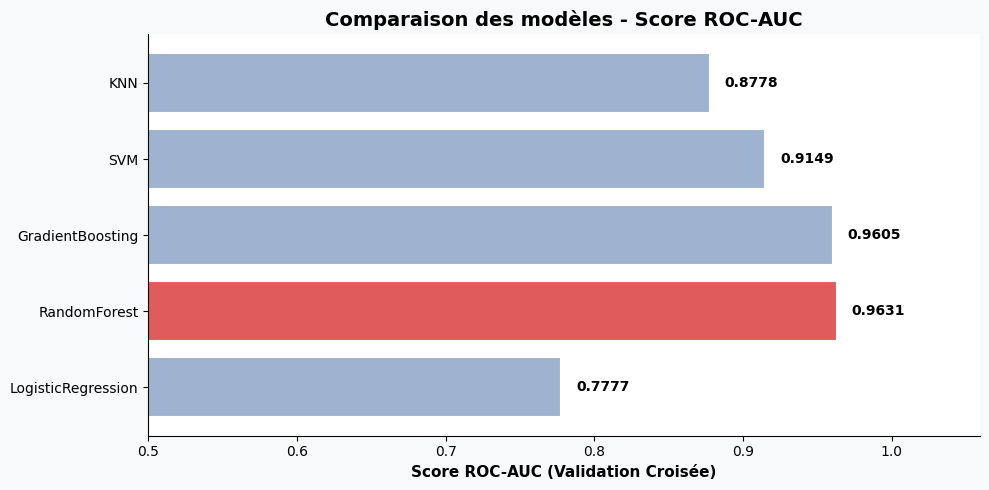


Résumé de la comparaison:
            Modèle  ROC-AUC
LogisticRegression 0.777741
      RandomForest 0.963140
  GradientBoosting 0.960501
               SVM 0.914916
               KNN 0.877784


In [32]:
# Créer un graphique de comparaison des modèles
comparison_df = pd.DataFrame({
    'Modèle': list(results_models.keys()),
    'ROC-AUC': [results_models[m]['cv_score'] for m in results_models.keys()],
})

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(comparison_df['Modèle'], comparison_df['ROC-AUC'], 
               color=[SNS_PALETTE[1] if m == best_model_name else '#9DB3D0' for m in comparison_df['Modèle']],
               edgecolor='white', linewidth=1.5)
ax.set_xlabel('Score ROC-AUC (Validation Croisée)', fontweight='bold')
ax.set_title('Comparaison des modèles - Score ROC-AUC', fontsize=14, fontweight='bold')
ax.set_xlim([0.5, max(comparison_df['ROC-AUC']) * 1.1])

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, comparison_df['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nRésumé de la comparaison:")
print(comparison_df.to_string(index=False))

---
## **7. Évaluation du meilleur modèle sur le test set**

> ⚠️ Cette section ne doit être exécutée **qu'une seule fois**, à la toute fin.
> Ajuster le modèle après avoir consulté les métriques sur le test set constitue du **data snooping**.

In [33]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("="*70)
print(f"ÉVALUATION DU MEILLEUR MODÈLE SUR LE TEST SET : {best_model_name}")
print("="*70)
print(classification_report(y_test, y_pred, target_names=['Resté (0)', 'Parti (1)']))
print(f"\nROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall (Sensibilité) : {recall_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print("="*70)

ÉVALUATION DU MEILLEUR MODÈLE SUR LE TEST SET : RandomForest
              precision    recall  f1-score   support

   Resté (0)       0.94      1.00      0.97       740
   Parti (1)       0.99      0.67      0.80       142

    accuracy                           0.95       882
   macro avg       0.96      0.83      0.88       882
weighted avg       0.95      0.95      0.94       882


ROC-AUC Score : 0.9881
Recall (Sensibilité) : 0.6690
Precision : 0.9896
F1-Score : 0.7983


c:\Users\Gamas\Documents\RécupGithub\StableDiffusion\IA-groupe-02\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


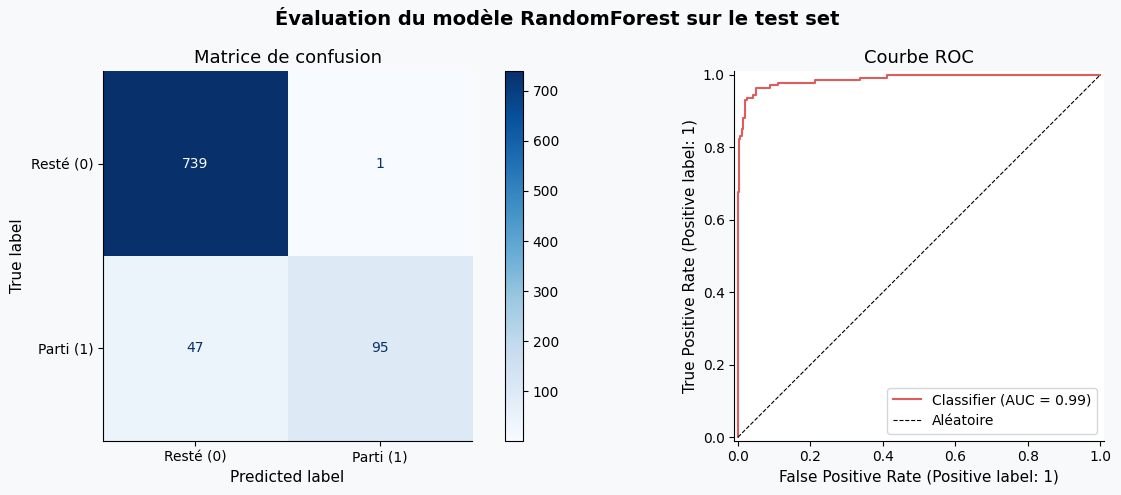

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Évaluation du modèle {best_model_name} sur le test set", fontsize=14, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Resté (0)', 'Parti (1)'],
    cmap='Blues', ax=axes[0],
)
axes[0].set_title("Matrice de confusion")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color=SNS_PALETTE[1])
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Aléatoire')
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## **8. Interprétabilité du modèle**

Un modèle prédictif déployé en contexte RH doit être **explicable** : l'EU AI Act (Art. 13)
impose une transparence sur les facteurs influençant les décisions automatisées.
Les feature importances permettent d'identifier quelles variables pèsent le plus dans les prédictions.

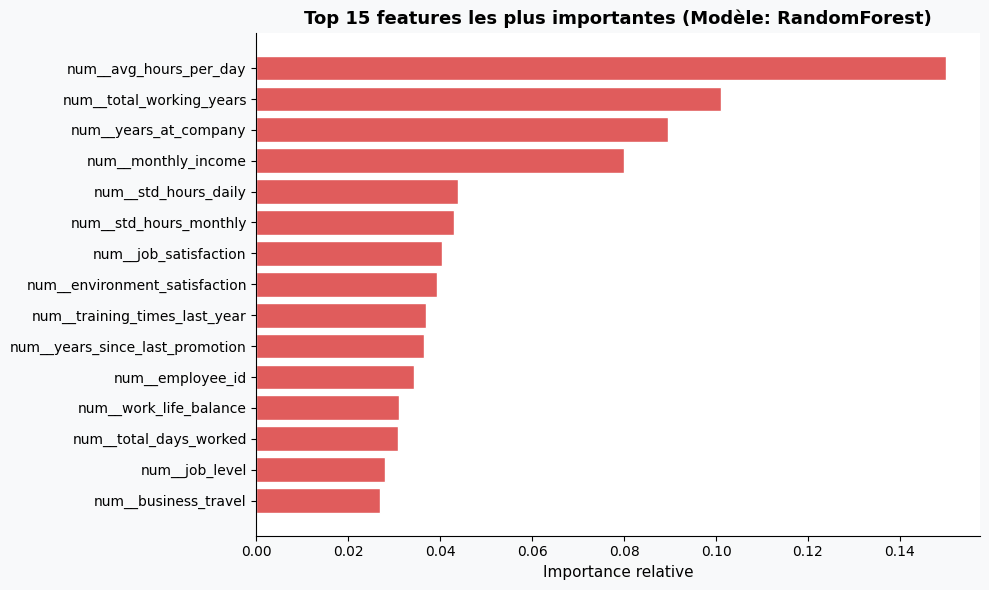

Top 10 features:
                        feature  importance
         num__avg_hours_per_day    0.149952
       num__total_working_years    0.101153
          num__years_at_company    0.089485
            num__monthly_income    0.079891
           num__std_hours_daily    0.043906
         num__std_hours_monthly    0.042962
          num__job_satisfaction    0.040449
  num__environment_satisfaction    0.039189
  num__training_times_last_year    0.036817
num__years_since_last_promotion    0.036418


In [35]:
best_pipe = best_model

# Récupération des noms de features après OneHotEncoding
feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()

# Extraire les importances selon le type de classifieur
classifier = best_pipe.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    # Tree-based (RandomForest, GradientBoosting)
    importances = classifier.feature_importances_
elif hasattr(classifier, 'coef_'):
    # LogisticRegression
    importances = np.abs(classifier.coef_[0])
else:
    importances = None

if importances is not None:
    importance_df = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['feature'], importance_df['importance'],
            color=SNS_PALETTE[1], edgecolor='white')
    ax.set_title(f'Top 15 features les plus importantes (Modèle: {best_model_name})', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance relative')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Top 10 features:")
    print(importance_df.head(10).to_string(index=False))
else:
    print(f"⚠️ Le modèle {best_model_name} ne fournit pas directement les importance des features.")